# Customer Churn Analysis
**Author:** Caroline Borges  
**Dataset:** IBM Telco Customer Churn ([Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn))  
**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## Business Context

In subscription-based businesses, retaining existing customers is significantly more cost-effective than acquiring new ones. Studies suggest that acquiring a new customer can cost **5x more** than retaining an existing one.

This analysis identifies behavioral and contractual patterns that predict customer churn, enabling data-driven retention strategies.

**Goal:** Understand *who* churns, *why*, and *what* the business can do about it.

| Detail | Info |
|---|---|
| Records | 7,043 customers |
| Features | 21 columns |
| Target variable | `Churn` (Yes / No) |
| Time scope | Single snapshot (last month) |

---

## Project Structure

```
1. Setup & Data Loading
2. ETL — Data Cleaning & Preparation
3. Exploratory Data Analysis (EDA)
4. Business Conclusions & Recommendations
```

> **Note:** This project focuses on depth over breadth — three key variables are analyzed thoroughly with business context and actionable recommendations.

---
## 1. Setup & Data Loading

In [818]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [819]:
base = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
base.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 2. ETL — Data Cleaning & Preparation

Before any analysis, we need to ensure the data is reliable. This section covers:
- Column types inspection
- Null and blank value detection
- Duplicate records check
- Data type corrections
- Feature engineering

### 2.1 Initial Inspection

Using `info()` to get an overview of column types, non-null counts, and memory usage.

In [820]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

> **Finding:** `TotalCharges` is typed as `object` (string) instead of `float64`. 
> This is a red flag — financial columns should always be numeric. This suggests hidden blank values that prevented automatic type inference.

### 2.2 Investigating `TotalCharges`

Checking for blank strings disguised as valid values — these are invisible to `isnull()` but break numeric operations.

In [821]:
blank_records = base[base['TotalCharges'] == ' ']
print(f"Records with blank TotalCharges: {len(blank_records)}")
blank_records[['customerID', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Records with blank TotalCharges: 11


,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Two year,52.55,,No
753,3115-CZMZD,0,Two year,20.25,,No
936,5709-LVOEQ,0,Two year,80.85,,No
1082,4367-NUYAO,0,Two year,25.75,,No
1340,1371-DWPAZ,0,Two year,56.05,,No
3331,7644-OMVMY,0,Two year,19.85,,No
3826,3213-VVOLG,0,Two year,25.35,,No
4380,2520-SGTTA,0,Two year,20.00,,No
5218,2923-ARZLG,0,One year,19.70,,No
6670,4075-WKNIU,0,Two year,73.35,,No


> **Root cause identified:** All 11 records with blank `TotalCharges` have `tenure = 0` — they are brand new customers who have not been billed yet.  
> **Decision:** Fill with `0` (not drop, not mean-impute), since these customers genuinely have no accumulated charges.

### 2.3 Fixing `TotalCharges` — Convert to Numeric

In [822]:
# Step 1: Convert to numeric — blank strings become NaN (errors='coerce')
base['TotalCharges'] = pd.to_numeric(base['TotalCharges'], errors='coerce')

# Step 2: Fill NaN with 0 (new customers with no billing history)
base['TotalCharges'] = base['TotalCharges'].fillna(0)

print(f"Remaining nulls in TotalCharges: {base['TotalCharges'].isnull().sum()}")
print(f"Data type: {base['TotalCharges'].dtype}")

Remaining nulls in TotalCharges: 0
Data type: float64


### 2.4 Checking for Duplicate Records

In [823]:
duplicates = base.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

Duplicate rows found: 0


> **Result:** No duplicate records found. Dataset integrity confirmed.

### 2.5 Fixing `SeniorCitizen` — Convert to Categorical

`SeniorCitizen` was encoded as `int64` (0/1), but it represents a category. Converting to `Yes`/`No` for consistency with other categorical columns.

In [824]:
base['SeniorCitizen'] = base['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(base['SeniorCitizen'].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


### 2.6 Feature Engineering — `churn_flag`

Creating a binary numeric version of the target variable to enable aggregations and rate calculations.

In [825]:
base['churn_flag'] = base['Churn'].map({'No': 0, 'Yes': 1})

### 2.7 ETL Summary

| Step | Action | Result |
|---|---|---|
| Type inspection | `df.info()` | Identified `TotalCharges` as string |
| Blank detection | Filter `== ' '` | Found 11 records (tenure = 0) |
| Type fix | `pd.to_numeric` + `fillna(0)` | `TotalCharges` now `float64` |
| Duplicates | `duplicated().sum()` | 0 duplicates found |
| Categorical fix | `.map()` on `SeniorCitizen` | Converted 0/1 → No/Yes |
| Feature engineering | `.map()` on `Churn` | Created `churn_flag` (0/1) |

**Dataset ready for analysis:** 7,043 rows × 22 columns, fully typed and clean.

---
## 3. Exploratory Data Analysis (EDA)

With clean data, we now explore the key patterns behind customer churn. This section focuses on three variables: **tenure**, **contract type**, and **monthly charges**.

### 3.1 Churn Distribution

Before diving into patterns, we need to understand the overall balance between 
churned and retained customers — and quantify the financial impact of churn.

In [826]:
total_clients = base['customerID'].value_counts().sum()

total_churn = base['churn_flag'].value_counts()[1]

perc_churn = (total_churn / total_clients) * 100

total_not_churn = base['churn_flag'].value_counts()[0]

perc_not_churn = (total_not_churn / total_clients) * 100

print(f"Total customers:   {total_clients}")
print(f"Total churned:     {total_churn} ({perc_churn:.1f}%)")
print(f"Total not churned: {total_not_churn} ({perc_not_churn:.1f}%)")

Total customers:   7043
Total churned:     1869 (26.5%)
Total not churned: 5174 (73.5%)


In [827]:
monthly_churned_revenue = base[base['churn_flag'] == 1]['MonthlyCharges'].sum()

yearly_churned_revenue = monthly_churned_revenue * 12

print(f"Monthly revenue at risk:    ${monthly_churned_revenue:,.2f}")
print(f"Annualized revenue at risk: ${yearly_churned_revenue:,.2f}")

Monthly revenue at risk:    $139,130.85
Annualized revenue at risk: $1,669,570.20


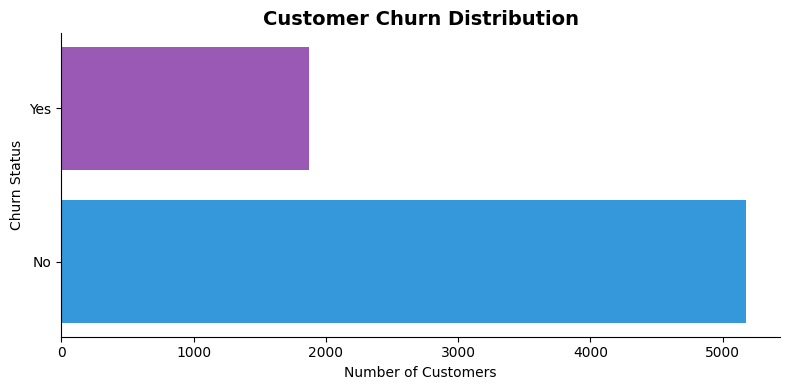

In [828]:
plt.figure(figsize=(8, 4))
churn_counts = base['Churn'].value_counts()

plt.barh(churn_counts.index, churn_counts.values, color=['#3498db', '#9b59b6'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Churn Status')
sns.despine()
plt.tight_layout()
plt.show()

> **Finding:** 26.5% of customers churned — a significant rate for a subscription 
> business. This translates to **$139,130 in monthly revenue at risk** ($1.67M annualized).
> 
> *Note: The annualized figure assumes a constant churn rate over 12 months — a simplified projection.*

### 3.2 Tenure Analysis — Churned vs Retained Customers

We start by calculating the **mean tenure** for each group as an initial reference point.

In [829]:
mean_tenure_churned = base[base['churn_flag'] == 1]['tenure'].mean()

mean_tenure_not_churned = base[base['churn_flag'] == 0]['tenure'].mean()

print(f"Average tenure of churned customers: {mean_tenure_churned:.2f} months. Meanwhile, the average tenure of non-churned customers is {mean_tenure_not_churned:.2f} months.")

Average tenure of churned customers: 17.98 months. Meanwhile, the average tenure of non-churned customers is 37.57 months.


However, mean alone can be misleading in skewed distributions. A single long-tenured 
customer (e.g., 72 months) can pull the average up, masking the real behavior of the majority.

To validate, we ran `describe()` and found:
- **High standard deviation (19.5)** relative to the mean (17.98) — confirms skewness
- **Median tenure of churned customers: 10 months** — much lower than the mean

In [830]:
base[base['churn_flag'] == 1]['tenure'].describe()

count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64

> **Conclusion:** Median is a more robust metric here — the high standard deviation 
> (19.5) confirms skewness. **50% of churners leave within the first 10 months**, 
> a classic early churn pattern that signals a critical onboarding window for retention.

The histogram below confirms this pattern visually — notice how churned customers 
(purple) are heavily concentrated in the 0–10 month range, while retained customers 
(blue) are more evenly distributed across all tenure ranges.

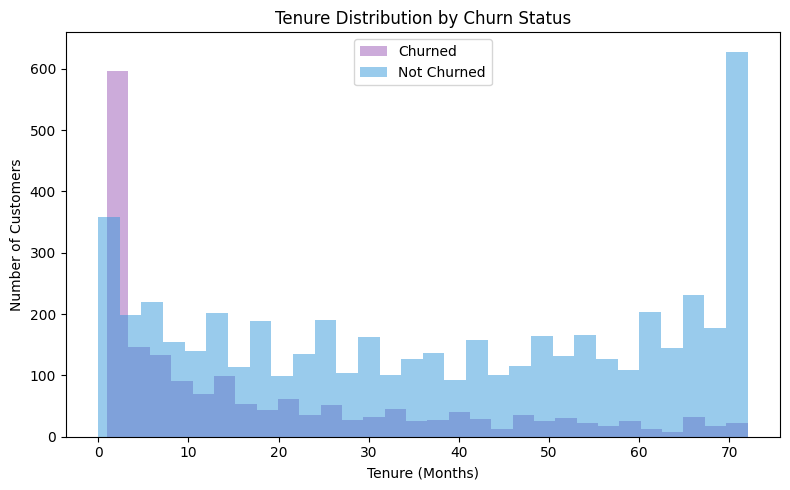

In [831]:
plt.figure(figsize=(8, 5))
plt.hist(base[base['churn_flag'] == 1]['tenure'], bins=30, alpha=0.5, color='#9b59b6', label='Churned')
plt.hist(base[base['churn_flag'] == 0]['tenure'], bins=30, alpha=0.5, color='#3498db', label='Not Churned')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

> **Key insight:** Customers who churn are 3x more likely to leave in the first 
> 10 months. This suggests the onboarding experience is a critical retention lever 
> — investing in the first year could significantly reduce early churn.

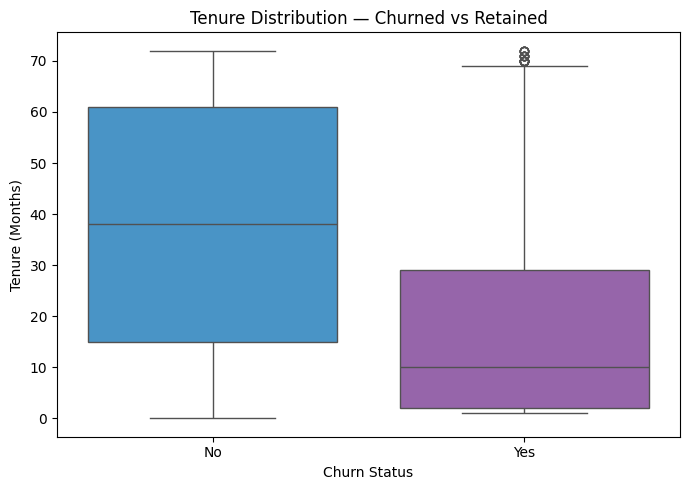

In [832]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='tenure', data=base, 
            hue='Churn', palette=['#3498db', '#9b59b6'], legend=False)
plt.title('Tenure Distribution — Churned vs Retained')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

> **Finding:** The boxplot confirms the early churn pattern — retained customers 
> (No) have a median tenure of ~38 months, while churned customers (Yes) have a 
> median of only 10 months. The wider box for retained customers also indicates 
> a more diverse tenure distribution, including many long-tenured loyal customers.

### 3.3 Contract Type Analysis
Contract type directly affects customer commitment level. We calculate the **churn 
rate per contract type** — not absolute counts — to avoid volume bias.

In [833]:
base['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

With 3,875 customers on month-to-month plans — the majority of the base — 
understanding churn rate per contract type is critical.

In [834]:
mean_contract_churned = base.groupby('Contract')['churn_flag'].mean() * 100
print(mean_contract_churned.round(1).astype(str) + '%')

Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: churn_flag, dtype: str


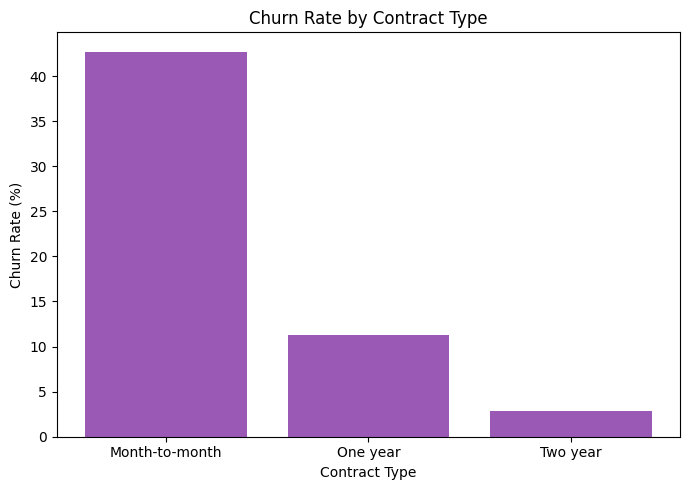

In [835]:
plt.figure(figsize=(7,5))
plt.bar(mean_contract_churned.index, mean_contract_churned, color = '#9b59b6')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

> **Key insight:** Month-to-month customers churn at **42%**, compared to 11% 
> for one-year and only 3% for two-year contracts — a **14x difference**. 
> This is the strongest churn predictor found in this analysis.

### 3.4 Monthly Charges Analysis
Exploring whether pricing is related to churn behavior — and to what extent.

In [836]:
mean_monthly_charges = base['MonthlyCharges'].mean()

mean_churned_monthly_charges = base[base['churn_flag'] == 1]['MonthlyCharges'].mean()

mean_notchurned_monthly_charges = base[base['churn_flag'] == 0]['MonthlyCharges'].mean()

print(f"The mean of the MonthlyCharges is ${mean_monthly_charges:.1f}, while the mean of monthly charges of churned clients is: ${mean_churned_monthly_charges:.1f} and of non churned clientes is: ${mean_notchurned_monthly_charges:.1f}")


The mean of the MonthlyCharges is $64.8, while the mean of monthly charges of churned clients is: $74.4 and of non churned clientes is: $61.3


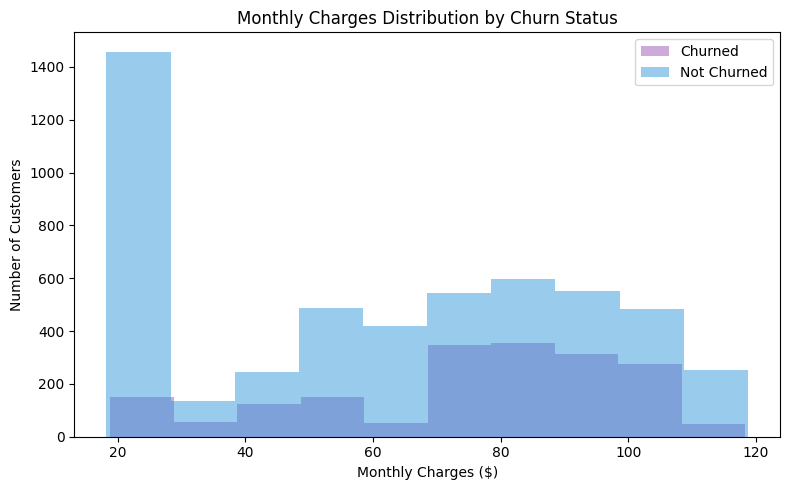

In [837]:
plt.figure(figsize=(8, 5))
plt.hist(base[base['churn_flag'] == 1]['MonthlyCharges'], alpha=0.5, color='#9b59b6', label='Churned')
plt.hist(base[base['churn_flag'] == 0]['MonthlyCharges'], alpha=0.5, color='#3498db', label='Not Churned')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

In [838]:
churned = base[base['churn_flag'] == 1]
range_20_40 = churned[churned['MonthlyCharges'] <= 40]
percentage = (len(range_20_40) / len(churned)) * 100
print(f"{percentage:.1f}%")

11.4%


In [839]:
not_churned = base[base['churn_flag'] == 0]
range_20_40 = not_churned[not_churned['MonthlyCharges'] <= 40]
percentage = (len(range_20_40) / len(not_churned)) * 100
print(f"{percentage:.1f}%")

31.4%


Only 11.4% of churned customers pay $20–40/month, compared to 31.4% of retained 
customers. The boxplot below shows the full distribution — confirming that churned 
customers tend to concentrate in higher price ranges.

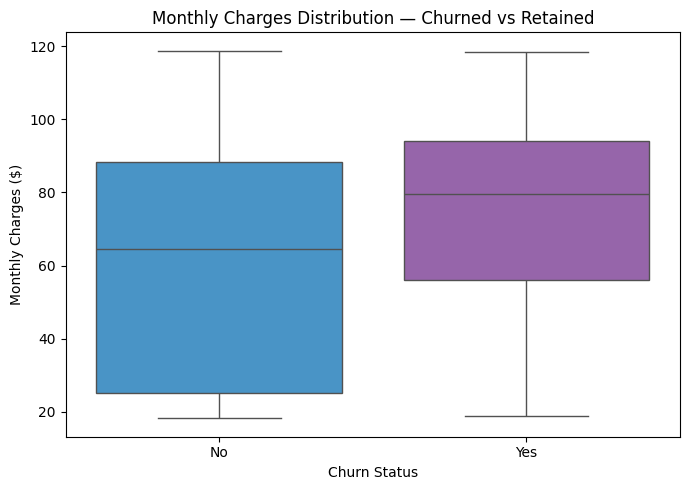

In [840]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=base,
            hue='Churn', palette=['#3498db', '#9b59b6'], legend=False)
plt.title('Monthly Charges Distribution — Churned vs Retained')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

> **Finding:** Churned customers have a higher median charge ($79) vs retained 
> customers ($64). This is a moderate relationship — likely reflecting the type 
> of services contracted rather than price sensitivity alone.

---
## 4. Business Conclusions & Recommendations

This analysis explored three key variables and their relationship with customer churn:
tenure, contract type, and monthly charges. Below are the main findings and recommended actions.

---

### Key Findings

| Variable | Finding |
|---|---|
| Overall churn rate | 26.5% - 1,869 out of 7,043 customers |
| Revenue at risk | $139,130/month ($1.67M annualized) |
| Contract type | Month-to-month customers churn at 42% vs 3% for two-year contracts |
| Tenure | 50% of churners leave within the first 10 months (early churn pattern) |
| Monthly charges | Churners have a higher median charge ($79) vs retained customers ($64) |

---

### Recommendations

**1. Migrate month-to-month customers to annual contracts**  
With 3,875 customers on monthly plans and a 42% churn rate, this is the highest-impact
action available. Offering a discount incentive (e.g. 10-15% off for annual commitment)
could significantly reduce churn while maintaining revenue.

**2. Invest in early retention programs (0-10 months)**  
The median tenure of churned customers is 10 months, indicating a critical onboarding
window. Loyalty programs, proactive support, or usage-based incentives during the first
year could reduce early churn substantially.

**3. Review pricing strategy for higher-cost tiers**  
Churned customers tend to pay higher monthly charges (median $79 vs $64 for retained).
While price alone is not the main driver, customers in higher-cost plans may not
perceive enough value - a review of service quality and upsell strategy is recommended.

---

### Final Note

Contract type and tenure are the strongest predictors of churn in this dataset. 
Monthly charges show a moderate relationship — churners pay more on average, but 
this likely reflects the services they contracted rather than price sensitivity alone.

**Further analysis recommended:** A deeper investigation into which specific services 
(e.g. TechSupport, OnlineSecurity, StreamingTV) correlate with churn could clarify 
whether MonthlyCharges is an independent driver or simply a proxy for service complexity. 
This would strengthen the pricing strategy recommendation significantly.

Addressing contract migration and early retention programs should remain the priority 
based on current findings.